# TR1 South Cluster-Galaxy Clustering Analysis (PZWAV & AMICO)

Analysis of TR1 South cluster-galaxy clustering as a function of redshift and galaxy type for both PZWAV and AMICO cluster finders.

**SNR Cuts Applied:**
- PZWAV: SNR > 5
- AMICO: SNR > 13

This notebook creates plots showing:
1. Single redshift bin comparison of galaxy types (separate for PZWAV & AMICO)
2. Redshift evolution for each galaxy type (separate for PZWAV & AMICO)
3. Galaxy type comparison across multiple redshift bins (separate for PZWAV & AMICO)
4. Direct comparison between PZWAV and AMICO cluster finders

## Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add src to path
sys.path.insert(0, '../src')
from plotting_utils import *

# Configuration
BASE_DIR = Path('../')
OUT = BASE_DIR / 'outputs/20260418'

richness_bins = [(5, 10), (10, 20), (20, 60), (60, 120), (120, 1000)]

def richness_dirs(finder):
    return {
        f'{gtype}_{r0}_{r1}': OUT / f'{finder}_{gtype}_richness_{r0}_{r1}'
        for gtype in ['all_galaxies', 'early_type', 'late_type']
        for r0, r1 in richness_bins
    }

output_dirs_pzwav = richness_dirs('pzwav')
output_dirs_amico = richness_dirs('amico')

redshift_bins = [(0.1, 0.4), (0.4, 0.7), (0.7, 1.0), (1.0, 1.3), (1.3, 1.6), (1.6, 1.9)]

FONT_SIZE_MINOR = 15
FONT_SIZE_MAJOR = 20
DEFAULT_Z_BIN = (0.4, 0.7)
DEFAULT_RICHNESS_BIN = (10, 20)

PLOT_OUTPUT_DIR = Path('plots_tr1_galaxy_type_analysis/20260418')
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Configuration loaded\!")
print(f"Plots will be saved to: {PLOT_OUTPUT_DIR}")
for finder, dirs in [('PZWAV', output_dirs_pzwav), ('AMICO', output_dirs_amico)]:
    found = sum(1 for d in dirs.values() if d.exists())
    print(f"{finder}: {found}/{len(dirs)} output directories found")


## Setup Plot Style

In [2]:
setup_plot_style(font_size_minor=FONT_SIZE_MINOR, font_size_major=FONT_SIZE_MAJOR)
print("Plot style configured")

Plot style configured


## Plot 1: Single Redshift Bin - Galaxy Type Comparison

Saved: plot1_type_comparison_pzwav.png


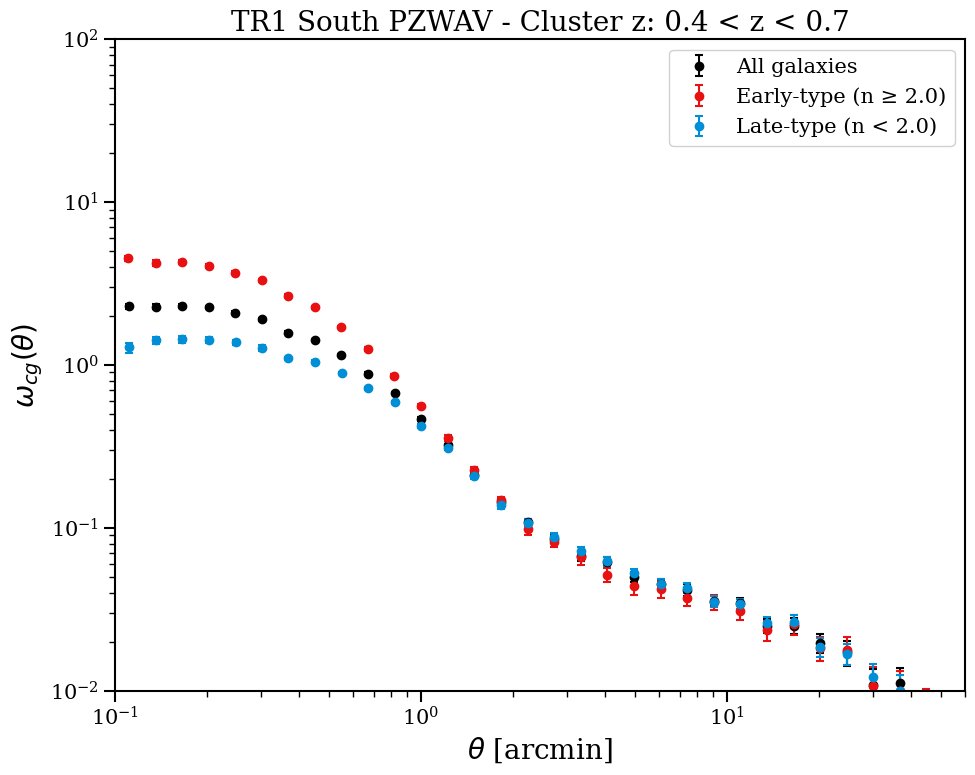

Saved: plot1_type_comparison_amico.png


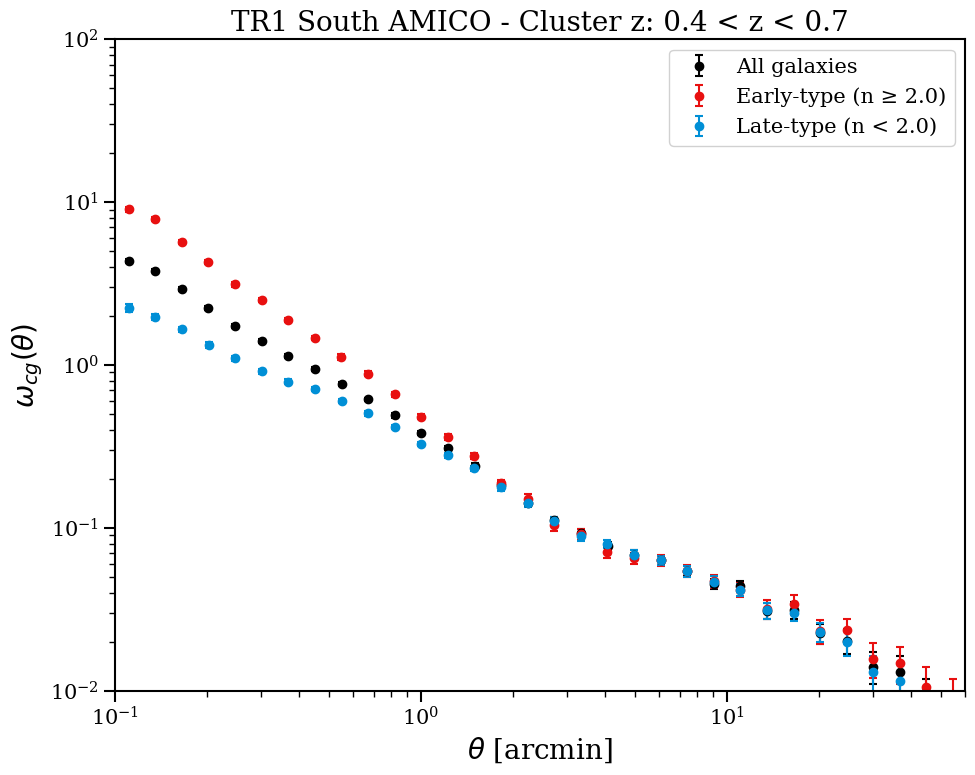

In [3]:
def plot_type_comparison_single_z(z_bin, output_dirs, cluster_name, output_file=None):
    fig, ax = plt.subplots(figsize=(10, 8))
    for gal_type in ['all', 'early', 'late']:
        files = find_result_files(output_dirs[gal_type], z_cluster_bin=z_bin, z_galaxy_bin=z_bin)
        if len(files) == 0:
            continue
        results = load_clustering_result(files[0])
        plot_correlation_function(ax, results['r'], results['xi'], results['sigma_xi'],
                                label=get_galaxy_type_label(gal_type),
                                color=get_galaxy_type_color(gal_type), marker='o', markersize=6)
    format_clustering_axis(ax, xlim=(0.1, 60), ylim=(1e-2, 1e2))
    ax.set_title(f"TR1 South {cluster_name} - Cluster z: {get_redshift_bin_label(*z_bin)}")
    plt.tight_layout()
    if output_file:
        plt.savefig(PLOT_OUTPUT_DIR / output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
    plt.show()

for finder, dirs in [('PZWAV', output_dirs_pzwav), ('AMICO', output_dirs_amico)]:
    plot_type_comparison_single_z(DEFAULT_Z_BIN, dirs, finder, f'plot1_type_comparison_{finder.lower()}.png')

## Plot 2: Redshift Evolution

Saved: plot2_redshift_evolution_pzwav.png


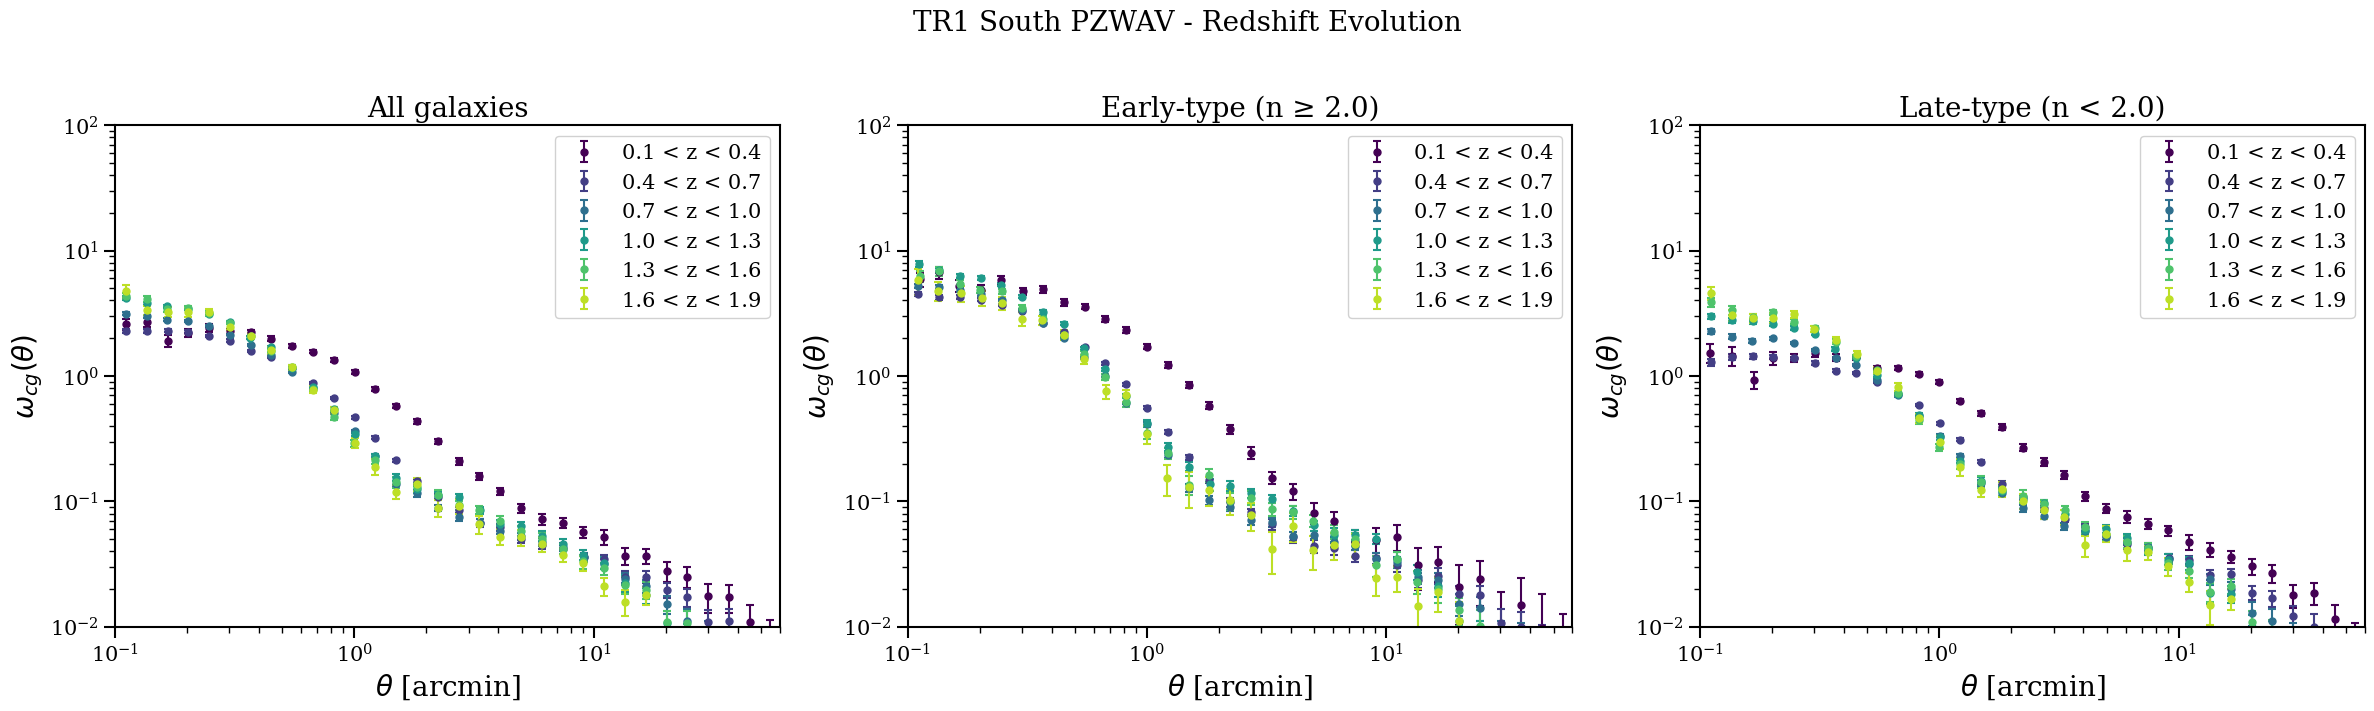

Saved: plot2_redshift_evolution_amico.png


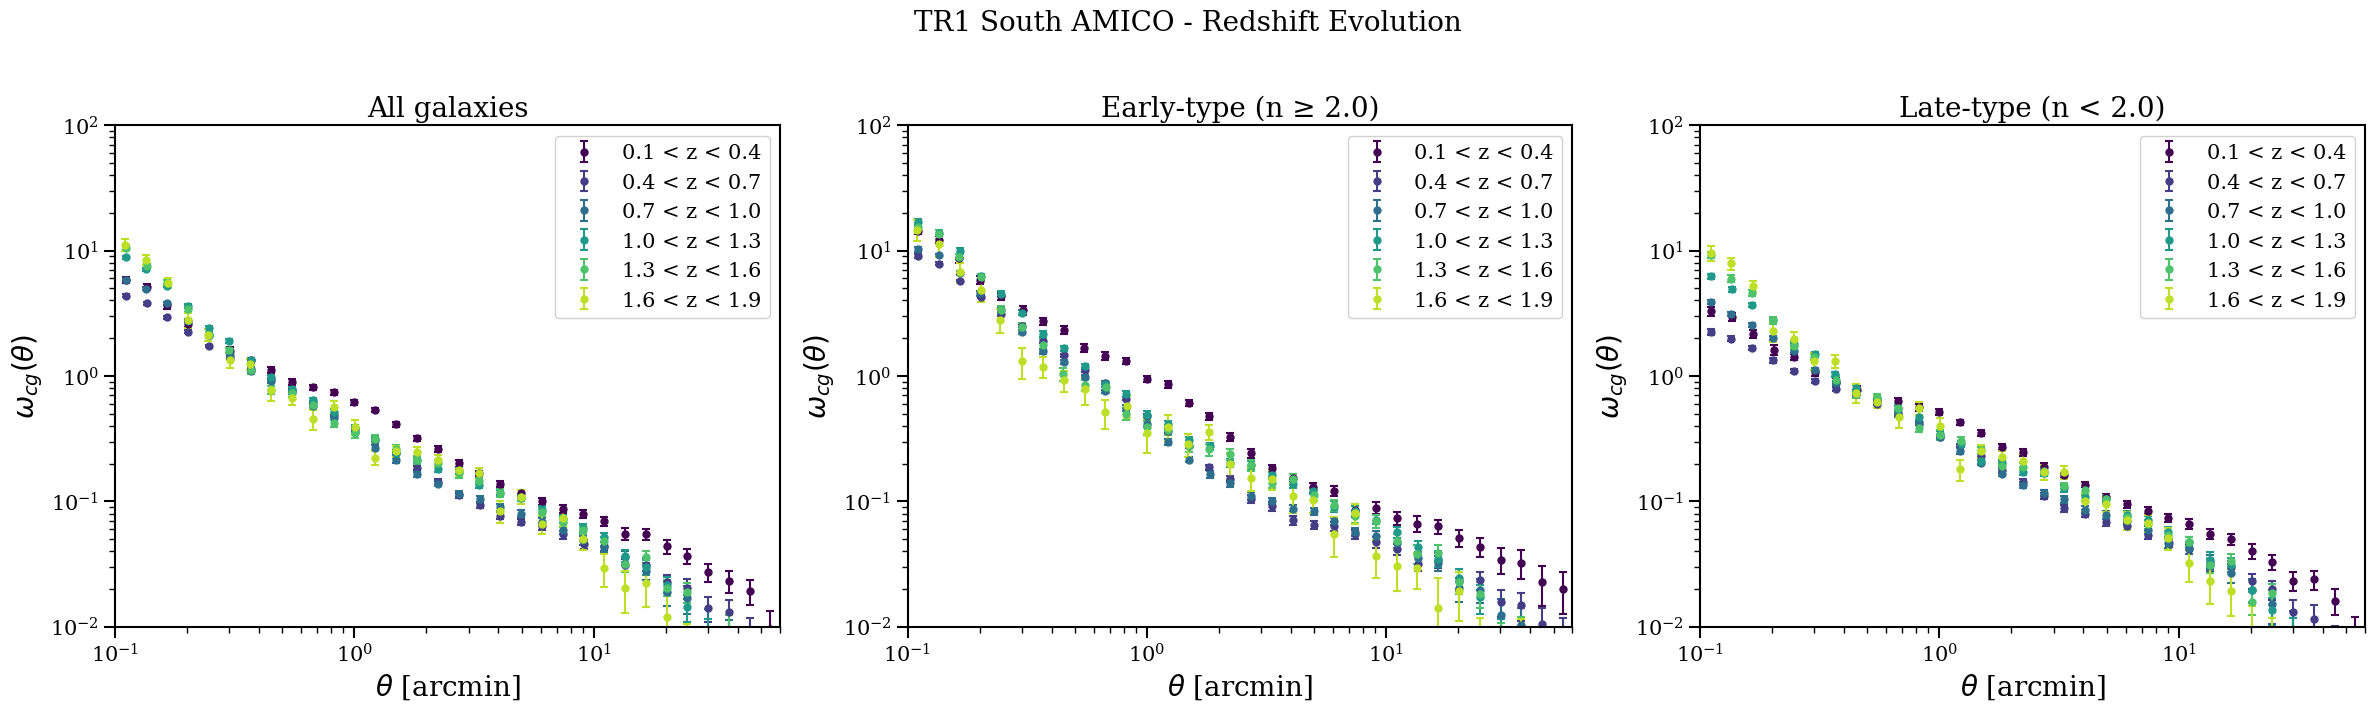

In [4]:
def plot_redshift_evolution(output_dirs, cluster_name, output_file=None):
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    z_colors = plt.cm.viridis(np.linspace(0, 0.9, len(redshift_bins)))
    for j, gal_type in enumerate(['all', 'early', 'late']):
        ax = axes[j]
        for i, z_bin in enumerate(redshift_bins):
            files = find_result_files(output_dirs[gal_type], z_cluster_bin=z_bin, z_galaxy_bin=z_bin)
            if len(files) == 0:
                continue
            results = load_clustering_result(files[0])
            plot_correlation_function(ax, results['r'], results['xi'], results['sigma_xi'],
                                    label=get_redshift_bin_label(*z_bin), color=z_colors[i],
                                    marker='o', markersize=5)
        format_clustering_axis(ax, xlim=(0.1, 60), ylim=(1e-2, 1e2))
        ax.set_title(get_galaxy_type_label(gal_type))
    fig.suptitle(f"TR1 South {cluster_name} - Redshift Evolution", fontsize=FONT_SIZE_MAJOR, y=1.02)
    plt.tight_layout()
    if output_file:
        plt.savefig(PLOT_OUTPUT_DIR / output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
    plt.show()

for finder, dirs in [('PZWAV', output_dirs_pzwav), ('AMICO', output_dirs_amico)]:
    plot_redshift_evolution(dirs, finder, f'plot2_redshift_evolution_{finder.lower()}.png')

## Plot 4: PZWAV vs AMICO Direct Comparison

Saved: plot3_pzwav_vs_amico_comparison.png


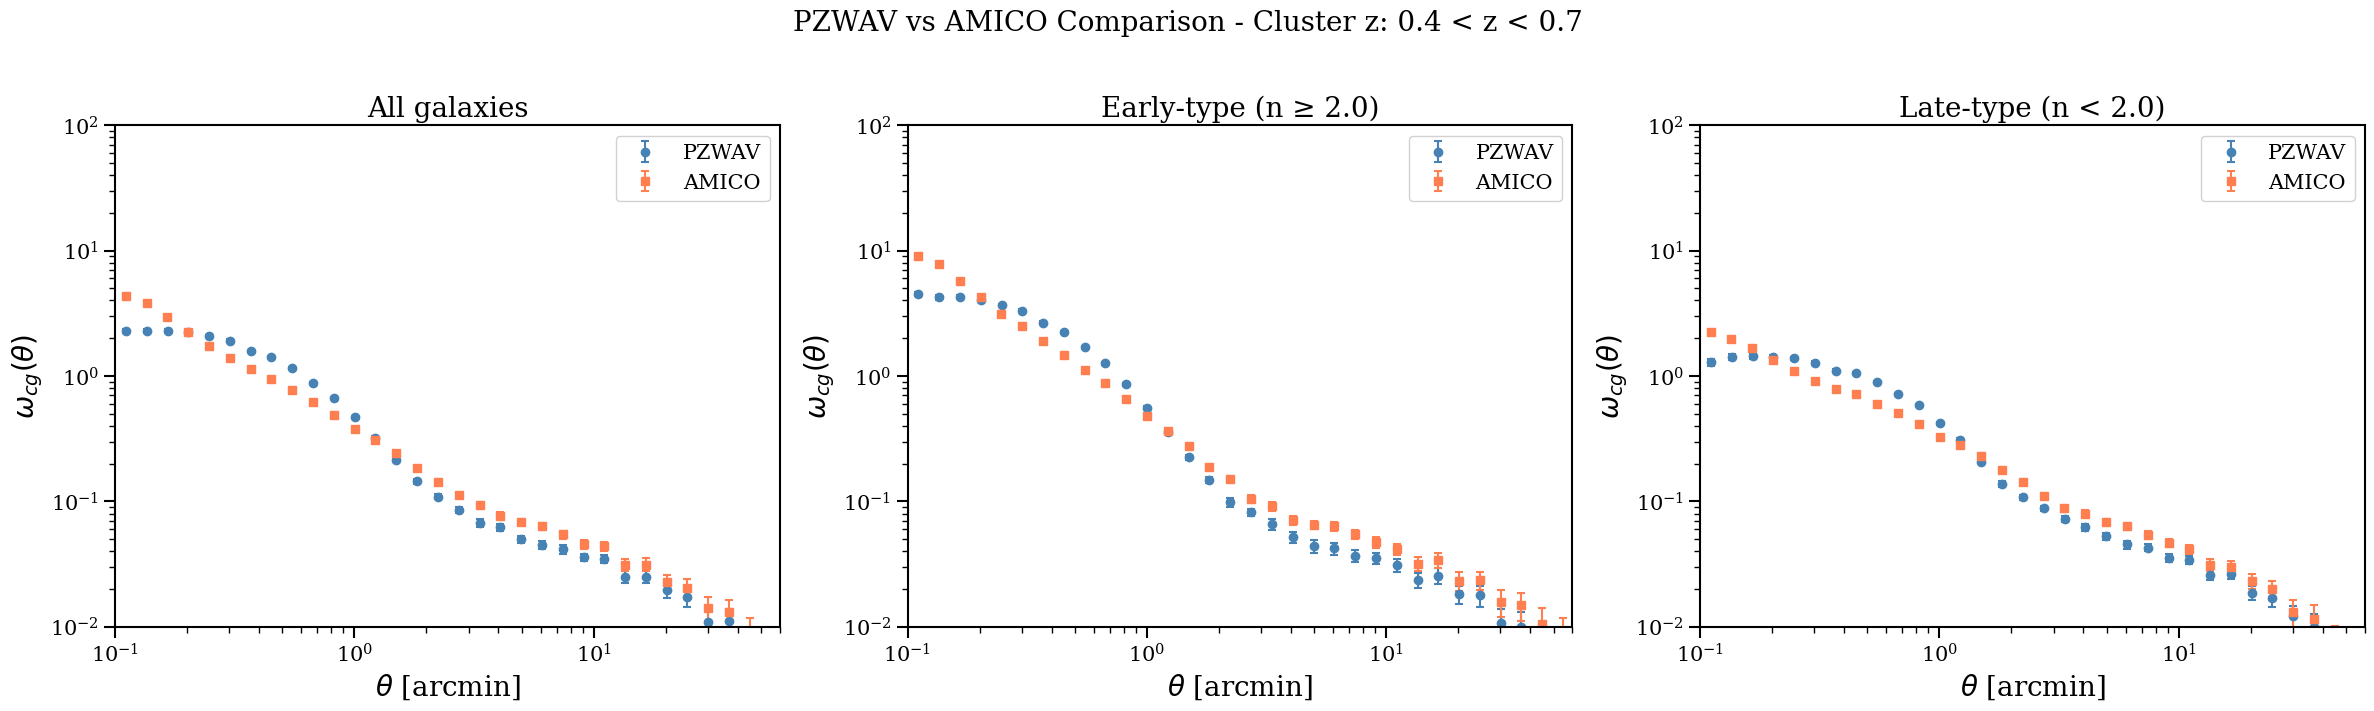

In [5]:
def plot_pzwav_vs_amico_comparison(z_bin, output_file=None):
    """Compare PZWAV vs AMICO for each galaxy type."""
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    for j, gal_type in enumerate(['all', 'early', 'late']):
        ax = axes[j]
        for finder, dirs, color, marker in [('PZWAV', output_dirs_pzwav, 'steelblue', 'o'), 
                                             ('AMICO', output_dirs_amico, 'coral', 's')]:
            files = find_result_files(dirs[gal_type], z_cluster_bin=z_bin, z_galaxy_bin=z_bin)
            if len(files) == 0:
                continue
            results = load_clustering_result(files[0])
            plot_correlation_function(ax, results['r'], results['xi'], results['sigma_xi'],
                                    label=finder, color=color, marker=marker, markersize=6)
        format_clustering_axis(ax, xlim=(0.1, 60), ylim=(1e-2, 1e2))
        ax.set_title(get_galaxy_type_label(gal_type))
    fig.suptitle(f"PZWAV vs AMICO Comparison - Cluster z: {get_redshift_bin_label(*z_bin)}", 
                 fontsize=FONT_SIZE_MAJOR, y=1.02)
    plt.tight_layout()
    if output_file:
        plt.savefig(PLOT_OUTPUT_DIR / output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
    plt.show()

plot_pzwav_vs_amico_comparison(DEFAULT_Z_BIN, 'plot3_pzwav_vs_amico_comparison.png')

## Plot 5: Galaxy Redshift Slices for Fixed Cluster Redshift (0.7 < z < 1.0)

Shows r × w_cg(r) for galaxies at different redshift slices when correlating with clusters at z=0.7-1.0.
Uses linear y-axis to show potential negative correlations.

Saved: plot5_galaxy_slices_clusterz07_10_pzwav_all.png


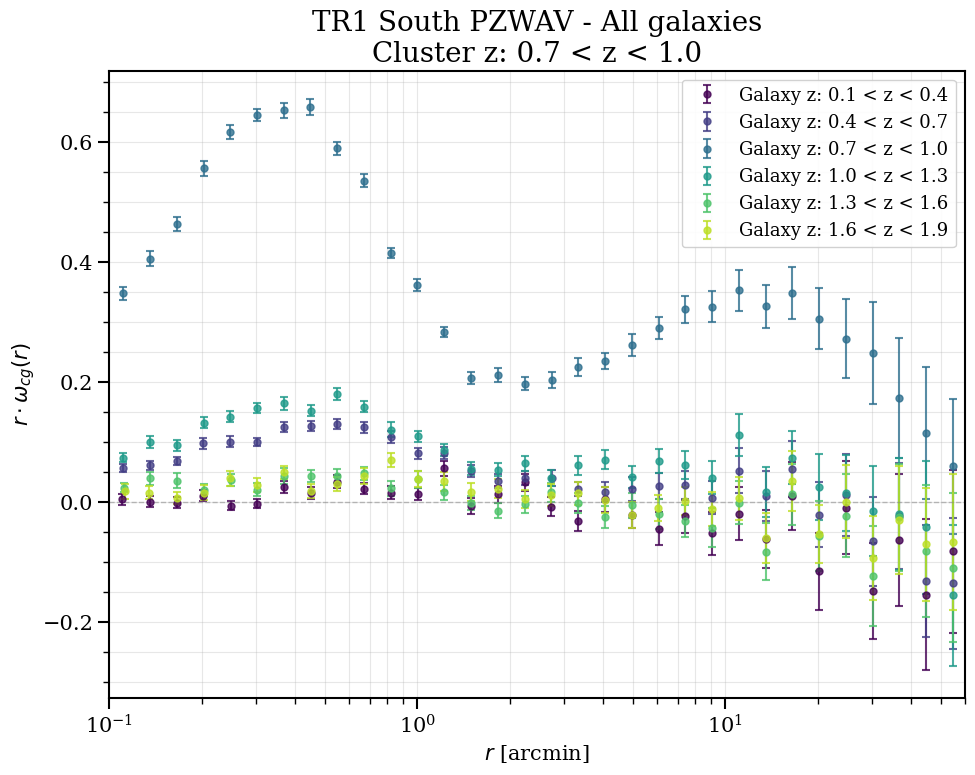

Saved: plot5_galaxy_slices_clusterz07_10_pzwav_early.png


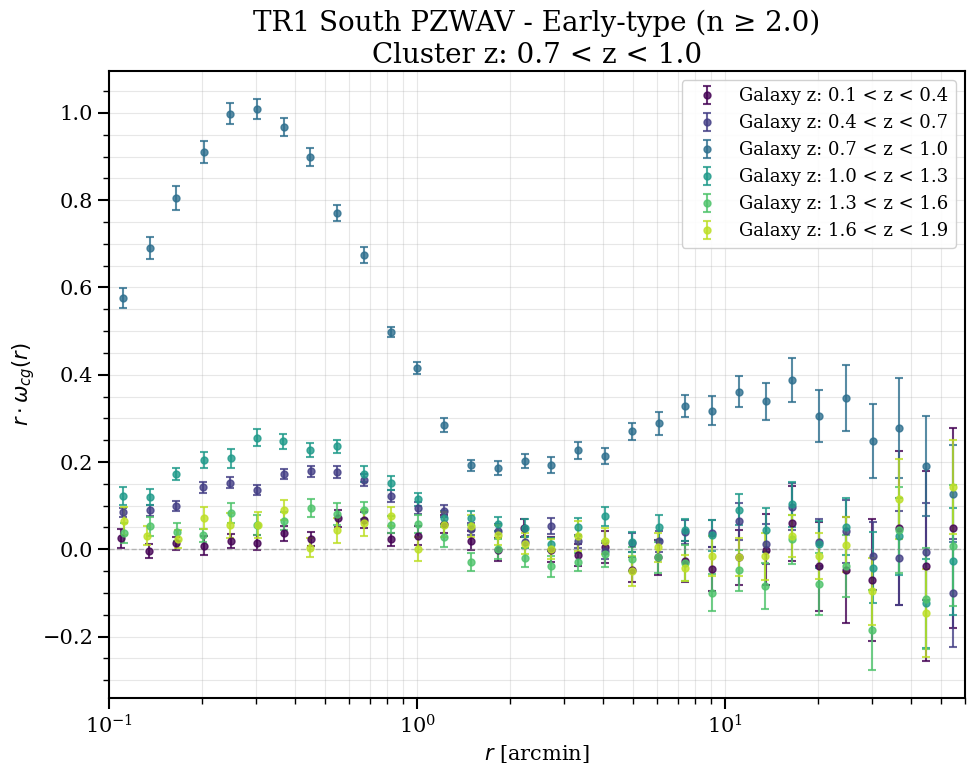

Saved: plot5_galaxy_slices_clusterz07_10_pzwav_late.png


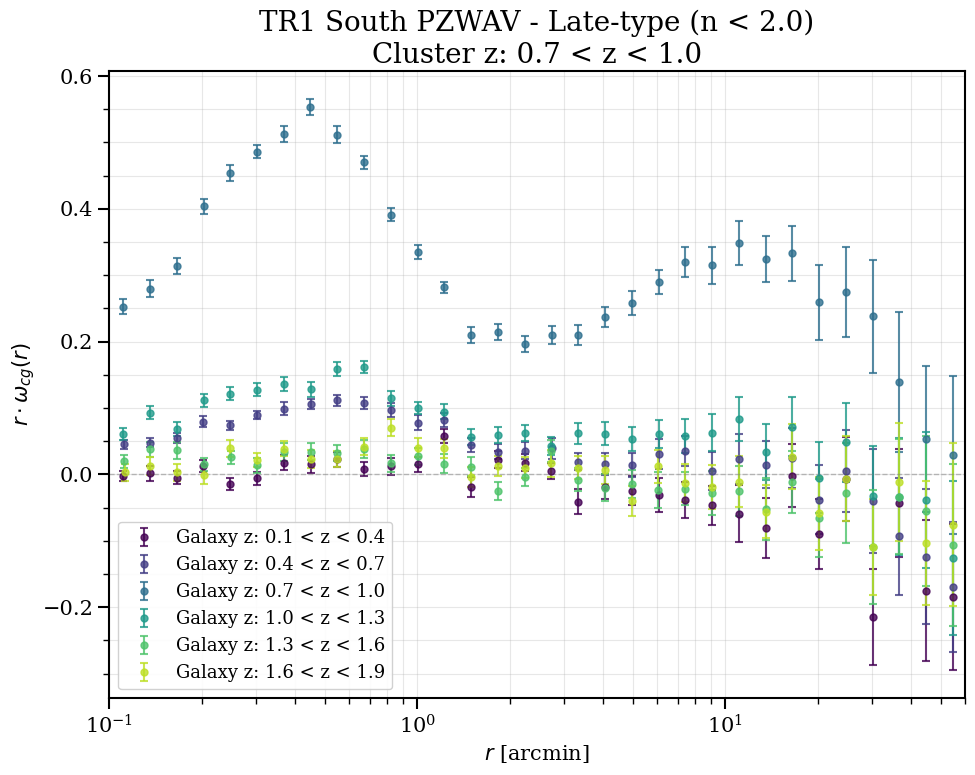

Saved: plot5_galaxy_slices_clusterz07_10_amico_all.png


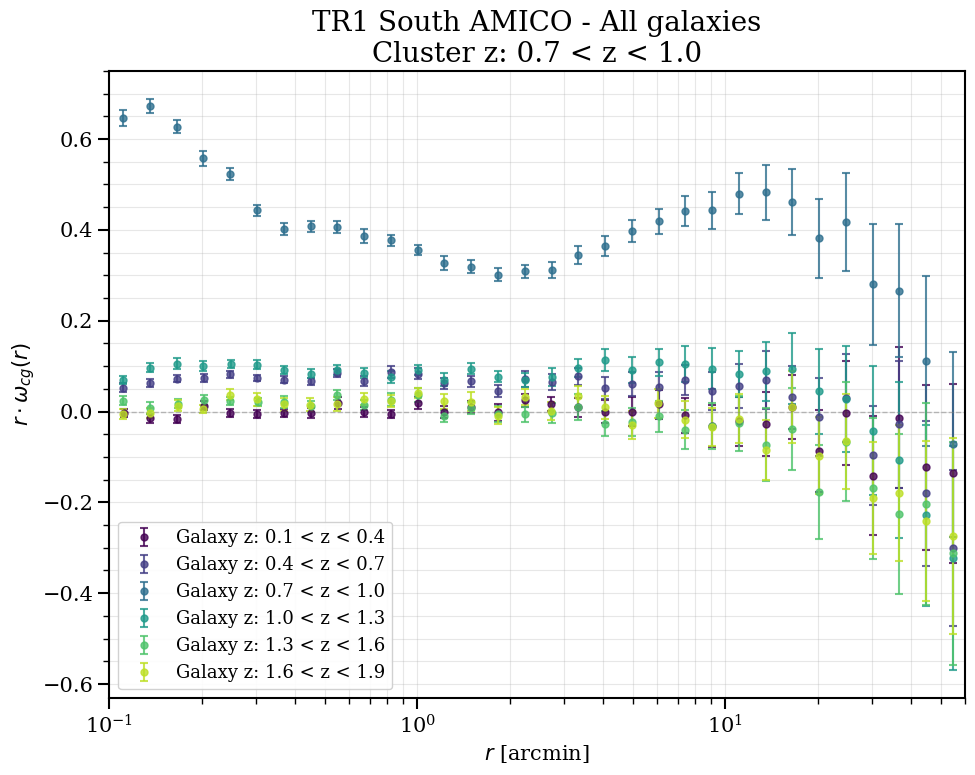

Saved: plot5_galaxy_slices_clusterz07_10_amico_early.png


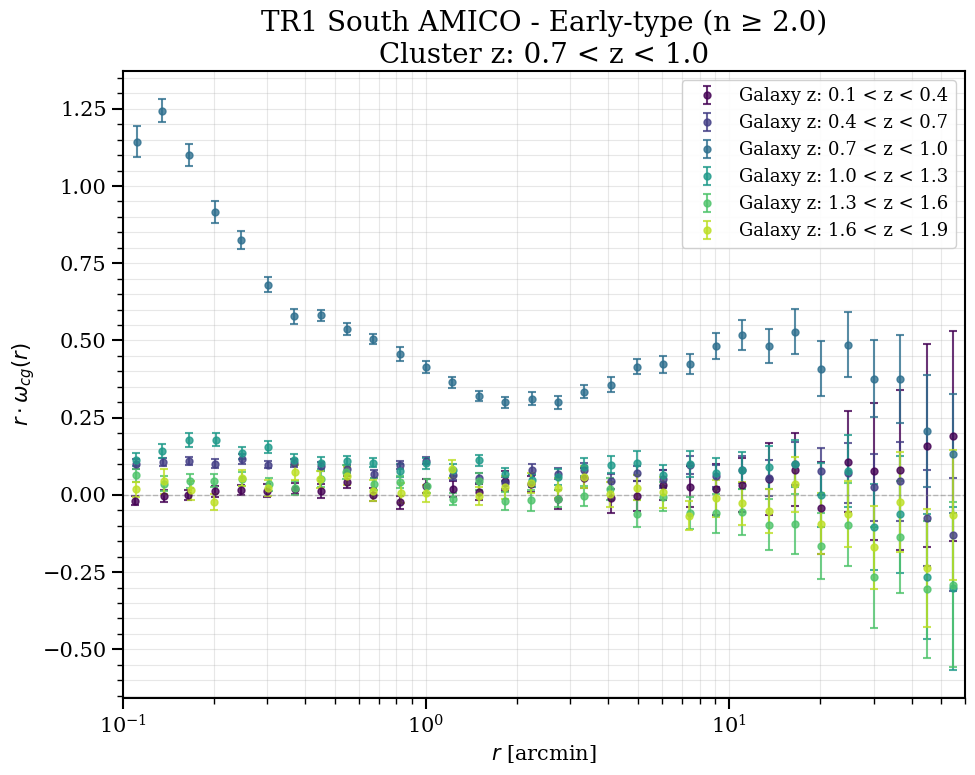

Saved: plot5_galaxy_slices_clusterz07_10_amico_late.png


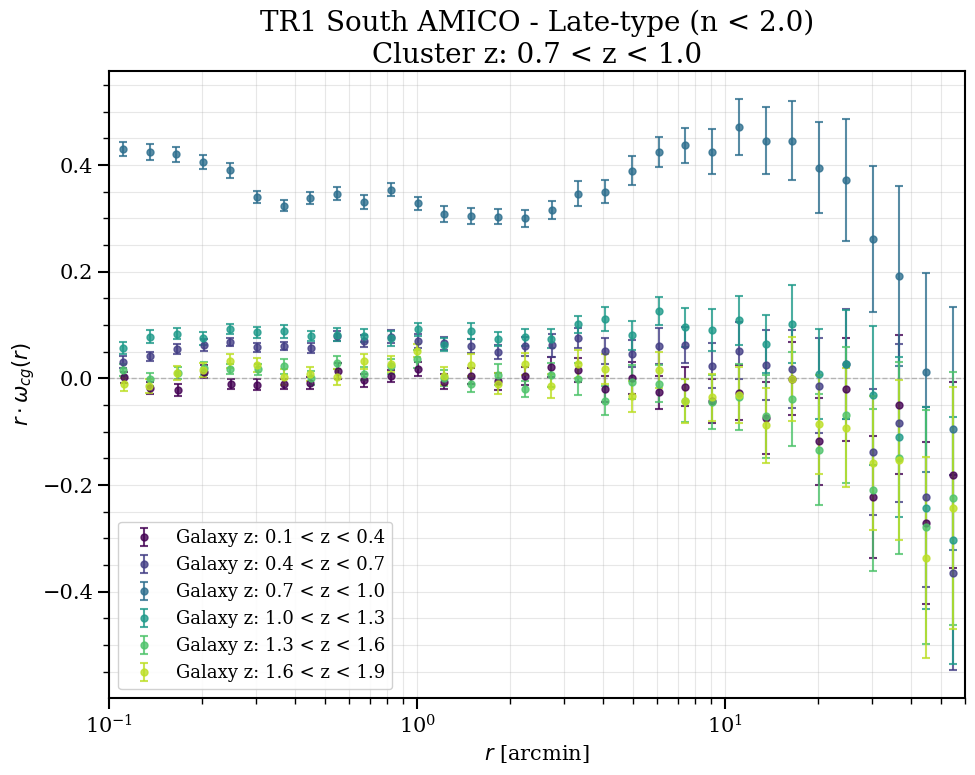


Note: This plot shows r × w_cg(r) with LINEAR y-axis to reveal negative correlations.
The horizontal dashed line marks zero correlation.


In [11]:
def plot_galaxy_redshift_slices(cluster_z_bin, output_dirs, cluster_name, gal_type='all', output_file=None):
    """
    Plot r × w_cg(r) for galaxies at different redshift slices for a fixed cluster redshift bin.
    Uses linear y-axis to show potential negative correlations.
    
    Parameters
    ----------
    cluster_z_bin : tuple
        Cluster redshift bin (z_min, z_max)
    output_dirs : dict
        Dictionary with keys 'all', 'early', 'late' pointing to output directories
    cluster_name : str
        Name of cluster finder (e.g., 'PZWAV', 'AMICO')
    gal_type : str
        Galaxy type: 'all', 'early', or 'late'
    output_file : str, optional
        Output filename
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Colors for different galaxy redshift bins
    z_colors = plt.cm.viridis(np.linspace(0, 0.9, len(redshift_bins)))
    
    # Plot each galaxy redshift slice
    for i, galaxy_z_bin in enumerate(redshift_bins):
        # Find result file for this cluster z bin and galaxy z bin
        files = find_result_files(
            output_dirs[gal_type],
            z_cluster_bin=cluster_z_bin,
            z_galaxy_bin=galaxy_z_bin
        )
        
        if len(files) == 0:
            continue
        
        # Load results
        results = load_clustering_result(files[0])
        
        # Plot r × w_cg(r) instead of just w_cg(r)
        r = results['r']
        xi = results['xi']
        sigma_xi = results['sigma_xi']
        
        # Multiply by r to emphasize different scales
        r_times_wcg = r * xi
        r_times_sigma = r * sigma_xi
        
        # Filter valid points
        valid = (r > 0) & np.isfinite(r_times_wcg) & np.isfinite(r_times_sigma) & (r_times_sigma > 0)
        
        ax.errorbar(
            r[valid], 
            r_times_wcg[valid], 
            yerr=r_times_sigma[valid],
            label=f"Galaxy z: {get_redshift_bin_label(*galaxy_z_bin)}",
            color=z_colors[i],
            marker='o',
            markersize=5,
            linestyle='none',
            capsize=3,
            capthick=1.5,
            alpha=0.8
        )
    
    # Format axis
    ax.set_xlabel(r'$r$ [arcmin]', fontsize=FONT_SIZE_MINOR)
    ax.set_ylabel(r'$r \cdot \omega_{cg}(r)$', fontsize=FONT_SIZE_MINOR)
    ax.set_xscale('log')
    # LINEAR y-axis to show negative correlations
    ax.set_xlim(0.1, 60)
    ax.legend(frameon=True, framealpha=0.9, fontsize=FONT_SIZE_MINOR-2, loc='best')
    ax.minorticks_on()
    ax.grid(True, alpha=0.3, which='both')
    
    # Add horizontal line at zero
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # Title
    title = f"TR1 South {cluster_name} - {get_galaxy_type_label(gal_type)}\n"
    title += f"Cluster z: {get_redshift_bin_label(*cluster_z_bin)}"
    ax.set_title(title, fontsize=FONT_SIZE_MAJOR)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(PLOT_OUTPUT_DIR / output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
    
    plt.show()

# Create plots for cluster z = 0.7-1.0 for both PZWAV and AMICO
cluster_z_bin = (0.7, 1.0)

for finder, dirs in [('PZWAV', output_dirs_pzwav), ('AMICO', output_dirs_amico)]:
    for gal_type in ['all', 'early', 'late']:
        plot_galaxy_redshift_slices(
            cluster_z_bin,
            dirs,
            finder,
            gal_type=gal_type,
            output_file=f'plot5_galaxy_slices_clusterz07_10_{finder.lower()}_{gal_type}.png'
        )

print("\nNote: This plot shows r × w_cg(r) with LINEAR y-axis to reveal negative correlations.")
print("The horizontal dashed line marks zero correlation.")

## Plot 3: Galaxy Type Comparison at Multiple Redshift Bins (1×3 Grid)

Shows galaxy type comparison (all/early/late) at 3 different redshift bins in a 1×3 grid layout.
Creates separate plots for PZWAV and AMICO.

Saved: plot3_type_comparison_multiple_z_pzwav.png


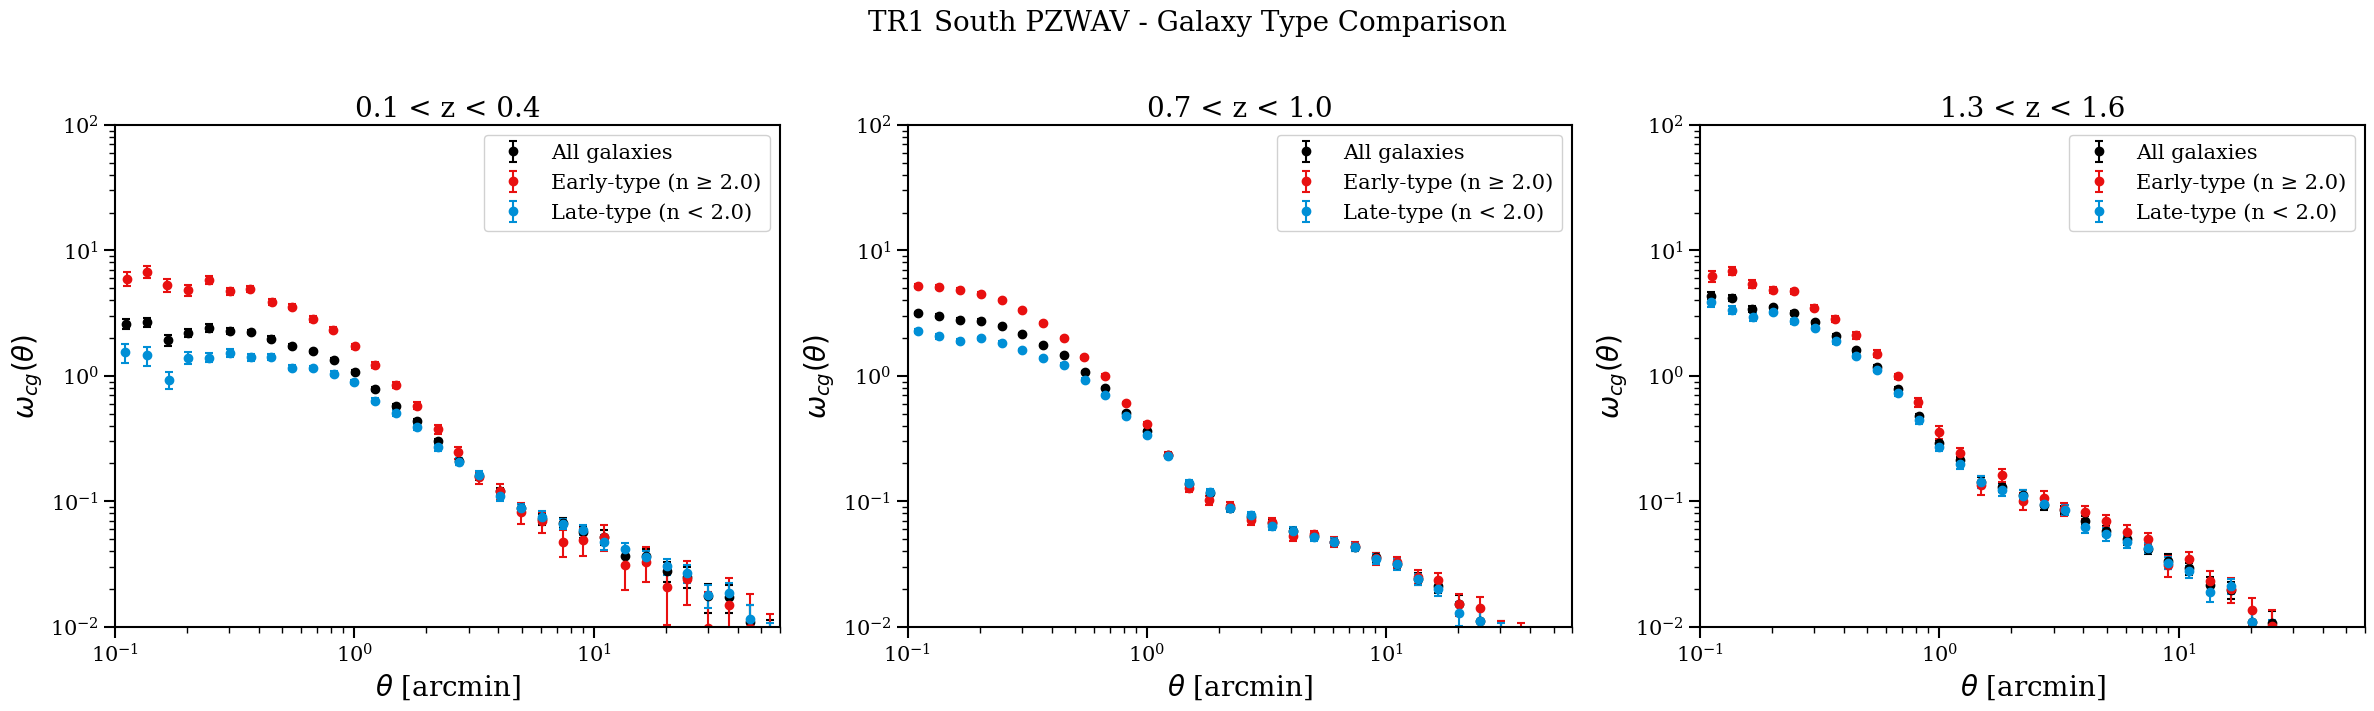

Saved: plot3_type_comparison_multiple_z_amico.png


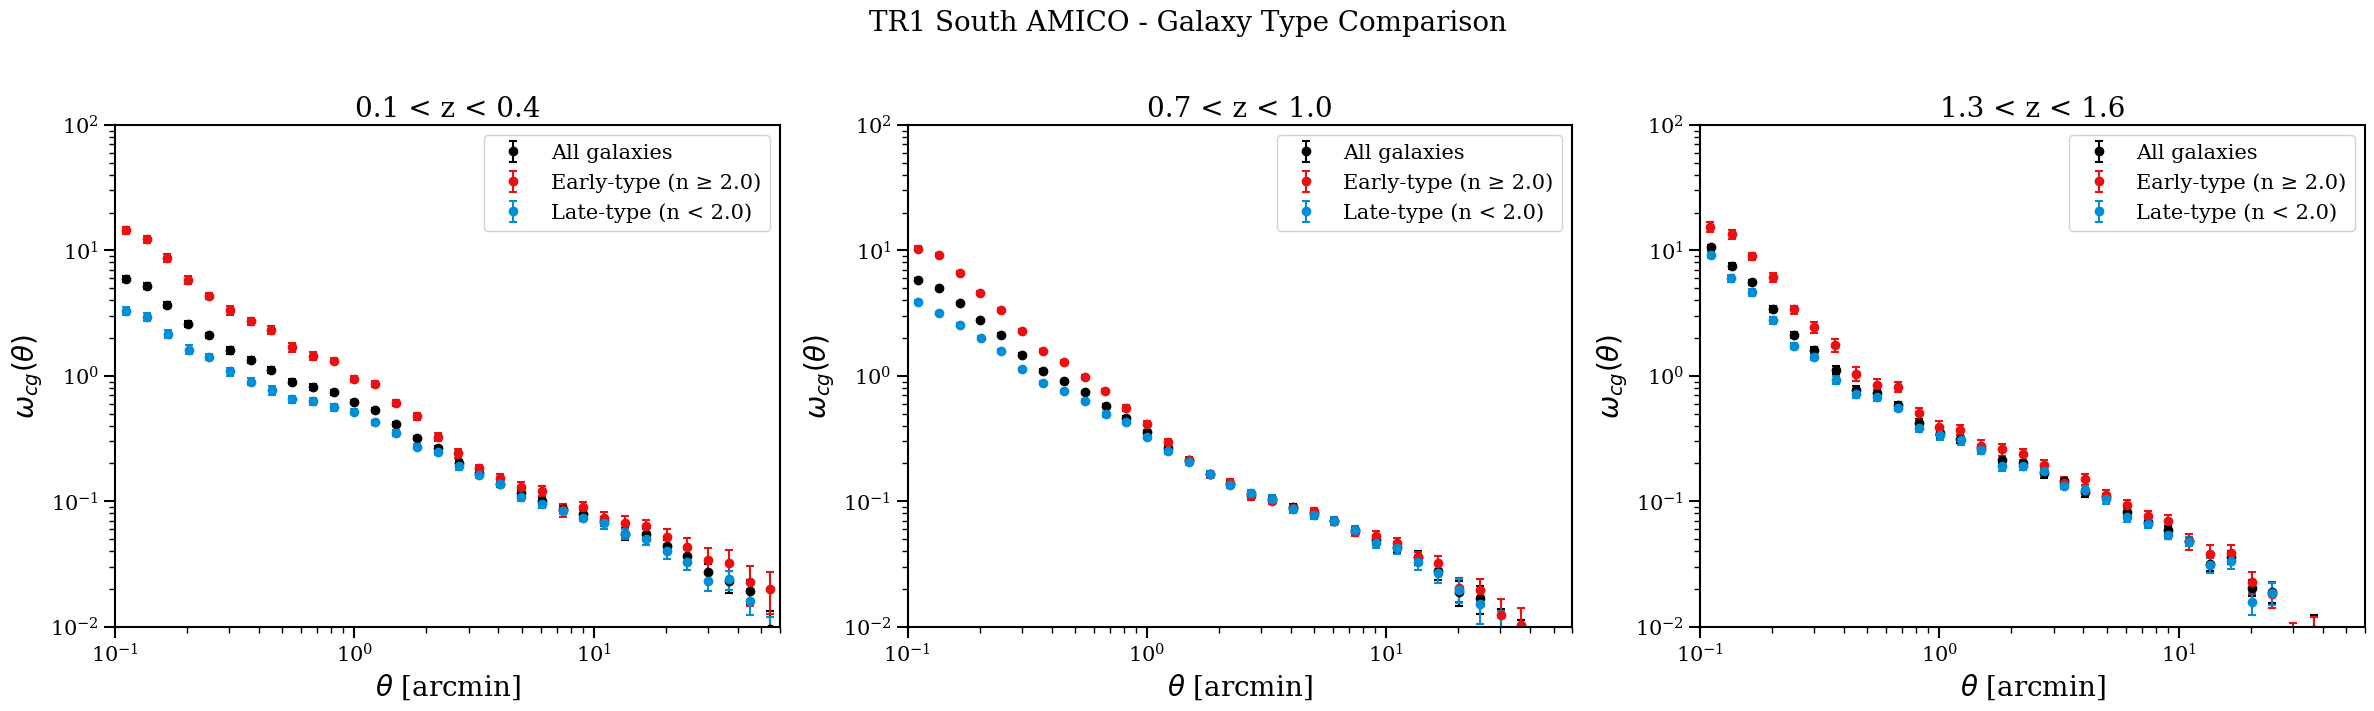

In [8]:
def plot_type_comparison_multiple_z(output_dirs, cluster_name, z_bins_to_plot=None, output_file=None):
    """
    Plot galaxy type comparison at multiple redshift bins in a 1x3 grid.
    
    Parameters
    ----------
    output_dirs : dict
        Dictionary with keys 'all', 'early', 'late' pointing to output directories
    cluster_name : str
        Name of cluster finder (e.g., 'PZWAV', 'AMICO')
    z_bins_to_plot : list of tuples, optional
        List of 3 redshift bins to plot. Default: [(0.1,0.4), (0.7,1.0), (1.3,1.6)]
    output_file : str, optional
        Output filename
    """
    if z_bins_to_plot is None:
        z_bins_to_plot = [(0.1, 0.4), (0.7, 1.0), (1.3, 1.6)]
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
    for i, z_bin in enumerate(z_bins_to_plot):
        ax = axes[i]
        
        # Plot each galaxy type
        for gal_type in ['all', 'early', 'late']:
            # Find result file
            files = find_result_files(
                output_dirs[gal_type],
                z_cluster_bin=z_bin,
                z_galaxy_bin=z_bin
            )
            
            if len(files) == 0:
                continue
            
            # Load results
            results = load_clustering_result(files[0])
            
            # Plot
            plot_correlation_function(
                ax, results['r'], results['xi'], results['sigma_xi'],
                label=get_galaxy_type_label(gal_type),
                color=get_galaxy_type_color(gal_type),
                marker='o', markersize=6
            )
        
        # Format axis
        format_clustering_axis(ax, xlim=(0.1, 60), ylim=(1e-2, 1e2))
        
        # Add subtitle for each panel
        ax.set_title(get_redshift_bin_label(*z_bin))
    
    # Overall title
    fig.suptitle(f"TR1 South {cluster_name} - Galaxy Type Comparison", 
                 fontsize=FONT_SIZE_MAJOR, y=1.02)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(PLOT_OUTPUT_DIR / output_file, dpi=300, bbox_inches='tight')
        print(f"Saved: {output_file}")
    
    plt.show()

# Create plots for both PZWAV and AMICO
z_bins_to_compare = [(0.1, 0.4), (0.7, 1.0), (1.3, 1.6)]

for finder, dirs in [('PZWAV', output_dirs_pzwav), ('AMICO', output_dirs_amico)]:
    plot_type_comparison_multiple_z(
        dirs, 
        finder, 
        z_bins_to_plot=z_bins_to_compare,
        output_file=f'plot3_type_comparison_multiple_z_{finder.lower()}.png'
    )

## Summary

In [7]:
print("\n" + "="*70)
print("PLOTTING COMPLETE")
print("="*70)
print(f"\nAll plots saved to: {PLOT_OUTPUT_DIR}")
print(f"\nGenerated plots:")
for plot_file in sorted(PLOT_OUTPUT_DIR.glob('*.png')):
    print(f"  - {plot_file.name}")


PLOTTING COMPLETE

All plots saved to: plots_tr1_galaxy_type_analysis

Generated plots:
  - plot1_type_comparison_amico.png
  - plot1_type_comparison_pzwav.png
  - plot1_type_comparison_single_z.png
  - plot2_redshift_evolution.png
  - plot2_redshift_evolution_amico.png
  - plot2_redshift_evolution_pzwav.png
  - plot3_pzwav_vs_amico_comparison.png
  - plot3_type_comparison_multiple_z.png
  - plot3_type_comparison_multiple_z_amico.png
  - plot3_type_comparison_multiple_z_pzwav.png
  - plot4_galaxy_slices_all.png
  - plot4_galaxy_slices_early.png
  - plot4_galaxy_slices_late.png
